CH.SC.U4CSE23248 Sriraam Vairavan R

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sn

decode data due to utf problems

In [27]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
csv_path = path + '/spam.csv'
data = pd.read_csv(csv_path, encoding='latin-1')

data = data[['v1', 'v2']]
data.columns = ['label', 'message']

data.head()


Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


email (data) pre-processing

In [15]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['message'])
y = data['label']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [18]:
y_pred = svm_model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9802690582959641

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.99      0.86      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115


Confusion Matrix:
 [[964   1]
 [ 21 129]]


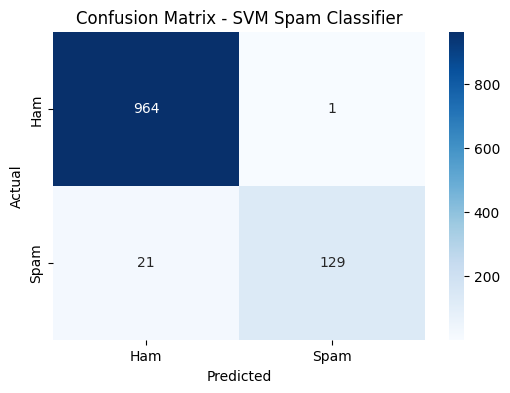

In [25]:
plt.figure(figsize=(6,4))
sn.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM Spam Classifier")
plt.show()